# 01 - Exploratory Data Analysis (EDA)
## Ames Housing Price Prediction: Advanced Regression Techniques

---

### 1. Problem Understanding & Technical Context
* **Objective:** Accurately predict final residential home sale prices in Ames, Iowa based on 79 explanatory features covering structural design, build quality, location, condition, and amenities.
* **Problem Type:** Supervised Regression with a continuous target variable (`SalePrice`).
* **Evaluation Metric:** **Root Mean Squared Logarithmic Error (RMSLE)**:
  $$\text{RMSLE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left( \log(\hat{y}_i + 1) - \log(y_i + 1) \right)^2 }$$
  Evaluating in log space ensures that predicting a relative percentage error is penalized equally across both affordable and luxury homes.

### 2. Objectives of this Notebook:
1. **Target Analysis:** Diagnose raw distribution, skewness, kurtosis, and evaluate normality under log transformation.
2. **Missing Value Diagnostics:** Differentiate structural absence (where `NA` signifies the feature does not exist) from random missingness.
3. **Feature Characterization:** Categorize numerical, ordinal, and nominal variables.
4. **Correlation & Multicollinearity:** Uncover primary linear drivers and identify redundant/collinear predictors.
5. **Outlier Detection:** Validate documented Ames Housing anomalies (e.g., Dean De Cock's $>4000$ sq ft partial sales).
6. **Actionable Roadmap:** Formalize concrete preprocessing steps for `02_preprocessing.ipynb`.


In [16]:
import os
import warnings
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.dpi'] = 120

# Output directory for saving report figures
FIG_DIR = os.path.join('..', 'outputs', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

print("Environment configured successfully. Figures will be saved to:", FIG_DIR)


Environment configured successfully. Figures will be saved to: ../outputs/figures


## 1. Data Ingestion & Shape Verification
We load both `train.csv` and `test.csv` to verify schema consistency, missingness scope, and record counts.


In [17]:
DATA_DIR = os.path.join('..', 'data')
train_path = os.path.join(DATA_DIR, 'train.csv')
test_path = os.path.join(DATA_DIR, 'test.csv')

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Training dataset: {train_df.shape[0]} rows x {train_df.shape[1]} columns")
print(f"Testing dataset:  {test_df.shape[0]} rows x {test_df.shape[1]} columns")

# Target verification
assert 'SalePrice' in train_df.columns, "Target 'SalePrice' missing from training set"
assert 'SalePrice' not in test_df.columns, "Target unexpectedly present in test set"

train_df.head(5)


Training dataset: 1460 rows x 81 columns
Testing dataset:  1459 rows x 80 columns


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [18]:
num_cols = train_df.select_dtypes(include=[np.number]).columns.drop(['Id', 'SalePrice']).tolist()
cat_cols = train_df.select_dtypes(include=['object']).columns.tolist()

print(f"Total Explanatory Features: {len(num_cols) + len(cat_cols)}")
print(f" - Numerical Features:   {len(num_cols)}")
print(f" - Categorical Features: {len(cat_cols)}")


Total Explanatory Features: 79
 - Numerical Features:   36
 - Categorical Features: 43


## 2. Target Variable Analysis (`SalePrice`)
Many linear and gradient-based models assume homoscedasticity and roughly normal errors.
Below we examine the distribution of `SalePrice` in both raw dollars and log-transformed space:
$$\tilde{y} = \log(1 + \text{SalePrice})$$


In [19]:
target = train_df['SalePrice']
log_target = np.log1p(target)

raw_stats = target.describe()
print("--- Raw SalePrice Summary ---")
for k, v in raw_stats.items():
    print(f"  {k:<8}: ${v:,.2f}")
print(f"  Skewness: {target.skew():.3f} (Pronounced right skew)")
print(f"  Kurtosis: {target.kurt():.3f} (Leptokurtic / heavy tailed)")

print()
print("--- Log-Transformed SalePrice Summary ---")
print(f"  Log Mean:     {log_target.mean():.4f}")
print(f"  Log Std Dev:  {log_target.std():.4f}")
print(f"  Log Skewness: {log_target.skew():.3f} (Near zero -> close to Gaussian)")
print(f"  Log Kurtosis: {log_target.kurt():.3f}")


--- Raw SalePrice Summary ---
  count   : $1,460.00
  mean    : $180,921.20
  std     : $79,442.50
  min     : $34,900.00
  25%     : $129,975.00
  50%     : $163,000.00
  75%     : $214,000.00
  max     : $755,000.00
  Skewness: 1.883 (Pronounced right skew)
  Kurtosis: 6.536 (Leptokurtic / heavy tailed)

--- Log-Transformed SalePrice Summary ---
  Log Mean:     12.0241
  Log Std Dev:  0.3994
  Log Skewness: 0.121 (Near zero -> close to Gaussian)
  Log Kurtosis: 0.810


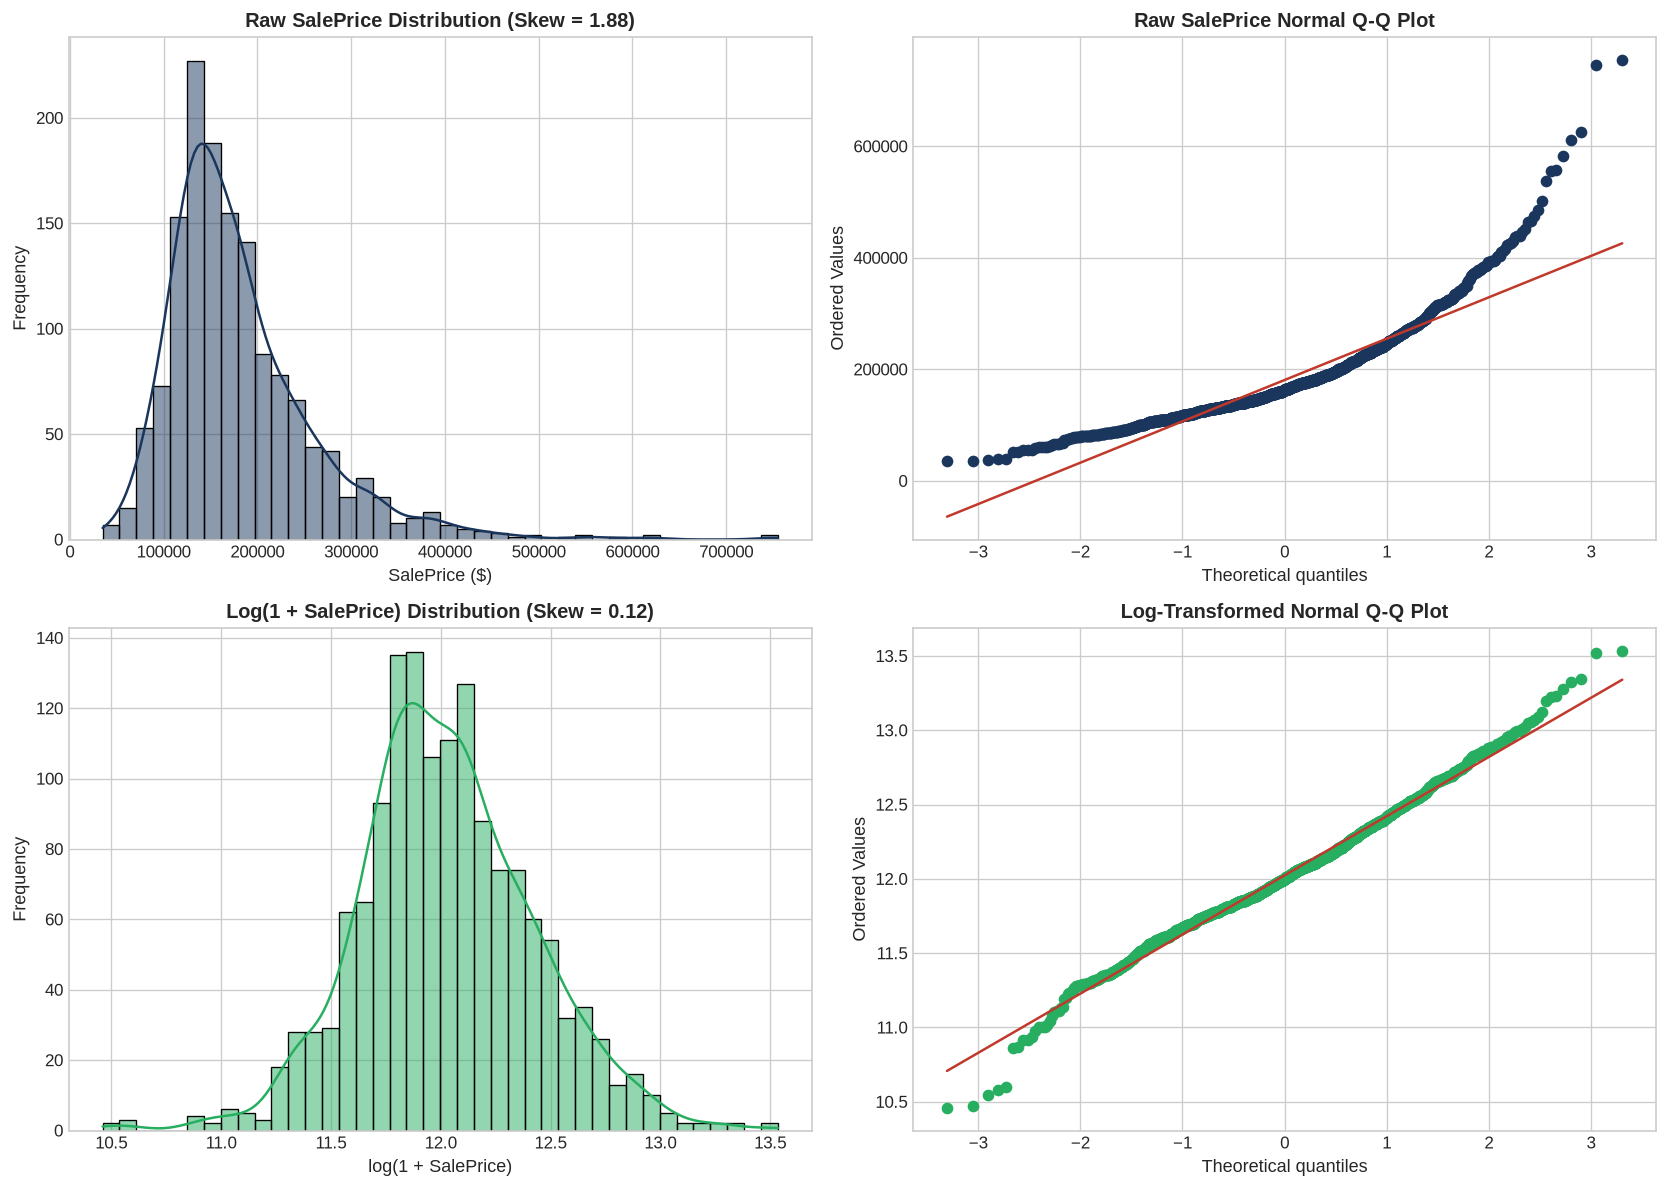

Saved figure: ../outputs/figures/01_target_distribution_and_log_transform.png


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Raw Distribution
sns.histplot(target, kde=True, ax=axes[0, 0], color='#1B365D', bins=40)
axes[0, 0].set_title(f'Raw SalePrice Distribution (Skew = {target.skew():.2f})', fontweight='bold')
axes[0, 0].set_xlabel('SalePrice ($)')
axes[0, 0].set_ylabel('Frequency')

# 2. Raw Q-Q Plot
stats.probplot(target, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Raw SalePrice Normal Q-Q Plot', fontweight='bold')
axes[0, 1].get_lines()[0].set_color('#1B365D')
axes[0, 1].get_lines()[1].set_color('#C0392B')

# 3. Log Distribution
sns.histplot(log_target, kde=True, ax=axes[1, 0], color='#27AE60', bins=40)
axes[1, 0].set_title(f'Log(1 + SalePrice) Distribution (Skew = {log_target.skew():.2f})', fontweight='bold')
axes[1, 0].set_xlabel('log(1 + SalePrice)')
axes[1, 0].set_ylabel('Frequency')

# 4. Log Q-Q Plot
stats.probplot(log_target, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Log-Transformed Normal Q-Q Plot', fontweight='bold')
axes[1, 1].get_lines()[0].set_color('#27AE60')
axes[1, 1].get_lines()[1].set_color('#C0392B')

plt.tight_layout()
fig_path = os.path.join(FIG_DIR, '01_target_distribution_and_log_transform.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved figure: {fig_path}")


**Takeaways on Target Distribution:**
1. Raw `SalePrice` departs significantly from normality with skewness of **1.88** and kurtosis of **6.54**.
2. Applying `np.log1p()` stabilizes the variance across price regimes, reducing skewness to **0.12** and aligning points closely along the normal theoretical quantiles.
3. **Pipeline Rule:** Model training will directly minimize RMSE on $\log(1 + \text{SalePrice})$. Predictions on the Kaggle test set will be inverted back to monetary values using `np.expm1()`.


## 3. Missing Value Diagnostics
In the Ames dataset, missing values (`NaN`) must be handled with domain context:
* **Structural Absence:** For features such as `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`, `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`. Here, `NA` indicates that the house simply **does not have that facility** (e.g., No Pool, No Garage, No Basement). They must be imputed with `"None"` (or `0` for numeric columns like `GarageArea`).
* **Stochastic Missingness:** Truly missing observations such as `LotFrontage` (linear feet of street frontage) or `Electrical`. These require statistical imputation.


In [21]:
all_features = pd.concat([train_df.drop('SalePrice', axis=1), test_df], axis=0).reset_index(drop=True)

missing = all_features.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(all_features)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': missing_pct,
    'Data Type': all_features[missing.index].dtypes
})

print(f"Total features with missing values (Train + Test): {len(missing_df)}")
missing_df.head(20)


Total features with missing values (Train + Test): 34


,Missing Count,Percentage (%),Data Type
PoolQC,2909,99.657417,str
MiscFeature,2814,96.402878,str
Alley,2721,93.216855,str
Fence,2348,80.438506,str
MasVnrType,1766,60.500171,str
FireplaceQu,1420,48.646797,str
LotFrontage,486,16.649538,float64
GarageQual,159,5.447071,str
GarageYrBlt,159,5.447071,float64
GarageCond,159,5.447071,str


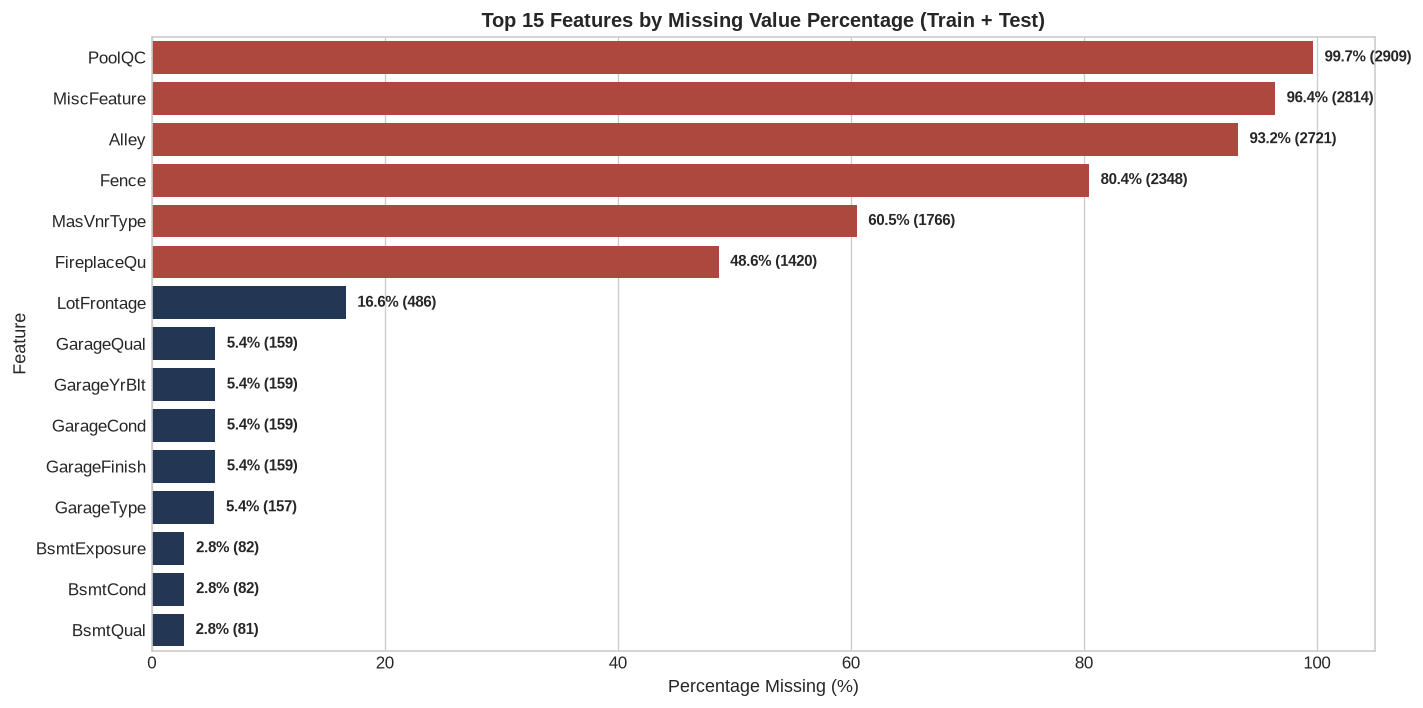

Saved figure: ../outputs/figures/02_missing_values_summary.png


In [22]:
plt.figure(figsize=(12, 6))
top_missing = missing_df.head(15)

palette = ['#C0392B' if p > 40 else '#1B365D' for p in top_missing['Percentage (%)']]
sns.barplot(x=top_missing['Percentage (%)'], y=top_missing.index, palette=palette)

plt.title('Top 15 Features by Missing Value Percentage (Train + Test)', fontweight='bold')
plt.xlabel('Percentage Missing (%)')
plt.ylabel('Feature')
plt.xlim(0, 105)

for idx, val in enumerate(top_missing['Percentage (%)']):
    count = int(top_missing['Missing Count'].iloc[idx])
    plt.text(val + 1, idx, f"{val:.1f}% ({count})", va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
fig_path = os.path.join(FIG_DIR, '02_missing_values_summary.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved figure: {fig_path}")


## 4. Correlation Analysis & Feature Multicollinearity
We compute Pearson correlation coefficients with `log_SalePrice` to determine the strongest linear predictors and evaluate multicollinearity among explanatory features.


In [23]:
train_corr_df = train_df[num_cols].copy()
train_corr_df['log_SalePrice'] = log_target

correlations = train_corr_df.corr()['log_SalePrice'].sort_values(ascending=False)
top_corrs = correlations[1:16]

print("Top 15 Features Positively Correlated with log(SalePrice):")
for f, r in top_corrs.items():
    print(f" - {f:<15}: r = {r:.3f}")


Top 15 Features Positively Correlated with log(SalePrice):
 - OverallQual    : r = 0.817
 - GrLivArea      : r = 0.701
 - GarageCars     : r = 0.681
 - GarageArea     : r = 0.651
 - TotalBsmtSF    : r = 0.612
 - 1stFlrSF       : r = 0.597
 - FullBath       : r = 0.595
 - YearBuilt      : r = 0.587
 - YearRemodAdd   : r = 0.566
 - GarageYrBlt    : r = 0.541
 - TotRmsAbvGrd   : r = 0.534
 - Fireplaces     : r = 0.489
 - MasVnrArea     : r = 0.431
 - BsmtFinSF1     : r = 0.372
 - LotFrontage    : r = 0.356


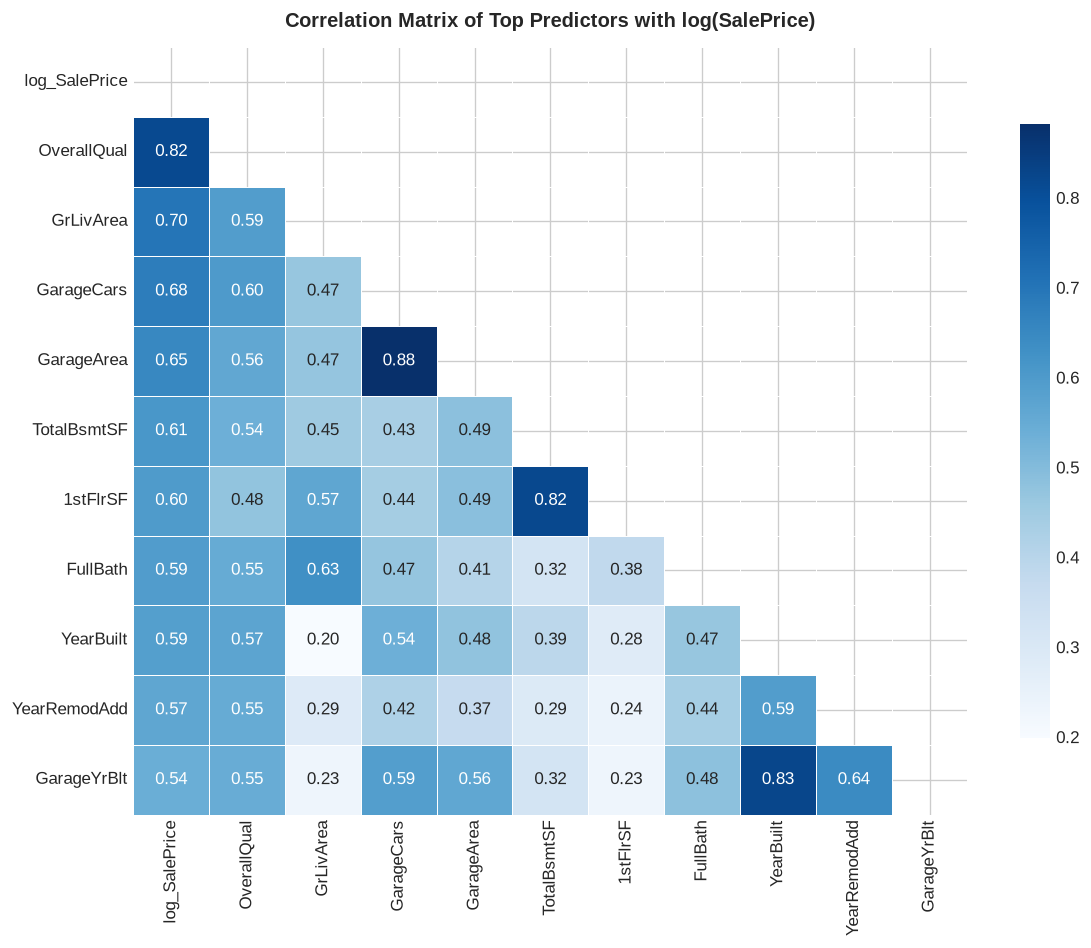

Saved figure: ../outputs/figures/03_correlation_heatmap.png


In [24]:
top_10_features = correlations.head(11).index

plt.figure(figsize=(10, 8))
corr_matrix = train_corr_df[top_10_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', mask=mask,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Top Predictors with log(SalePrice)', fontweight='bold', pad=12)

plt.tight_layout()
fig_path = os.path.join(FIG_DIR, '03_correlation_heatmap.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved figure: {fig_path}")


**Key Multicollinearity Insights:**
1. **Garage Redundancy:** `GarageCars` and `GarageArea` exhibit $r = 0.88$. They provide essentially identical capacity information; tree ensembles handle this naturally, but linear models require $L_1/L_2$ regularization.
2. **Floor & Basement Coupling:** `TotalBsmtSF` and `1stFlrSF` exhibit $r = 0.82$, as ground floor area strongly reflects basement footprint.
3. **Living Volume vs. Room Count:** `TotRmsAbvGrd` and `GrLivArea` exhibit $r = 0.83$. Total rooms above ground is collinear with total square footage.
4. **Temporal Alignment:** `YearBuilt` and `GarageYrBlt` exhibit $r = 0.83$, confirming garages are typically constructed at the time of house erection.


## 5. Primary Price Drivers Exploration
We visualize four crucial drivers across quality, physical size, location, and age:
* `OverallQual`: Overall material and finish quality (rated 1 to 10).
* `GrLivArea`: Above-grade (ground) living area in square feet.
* `Neighborhood`: Physical location within Ames city limits.
* `YearBuilt`: Original construction date.


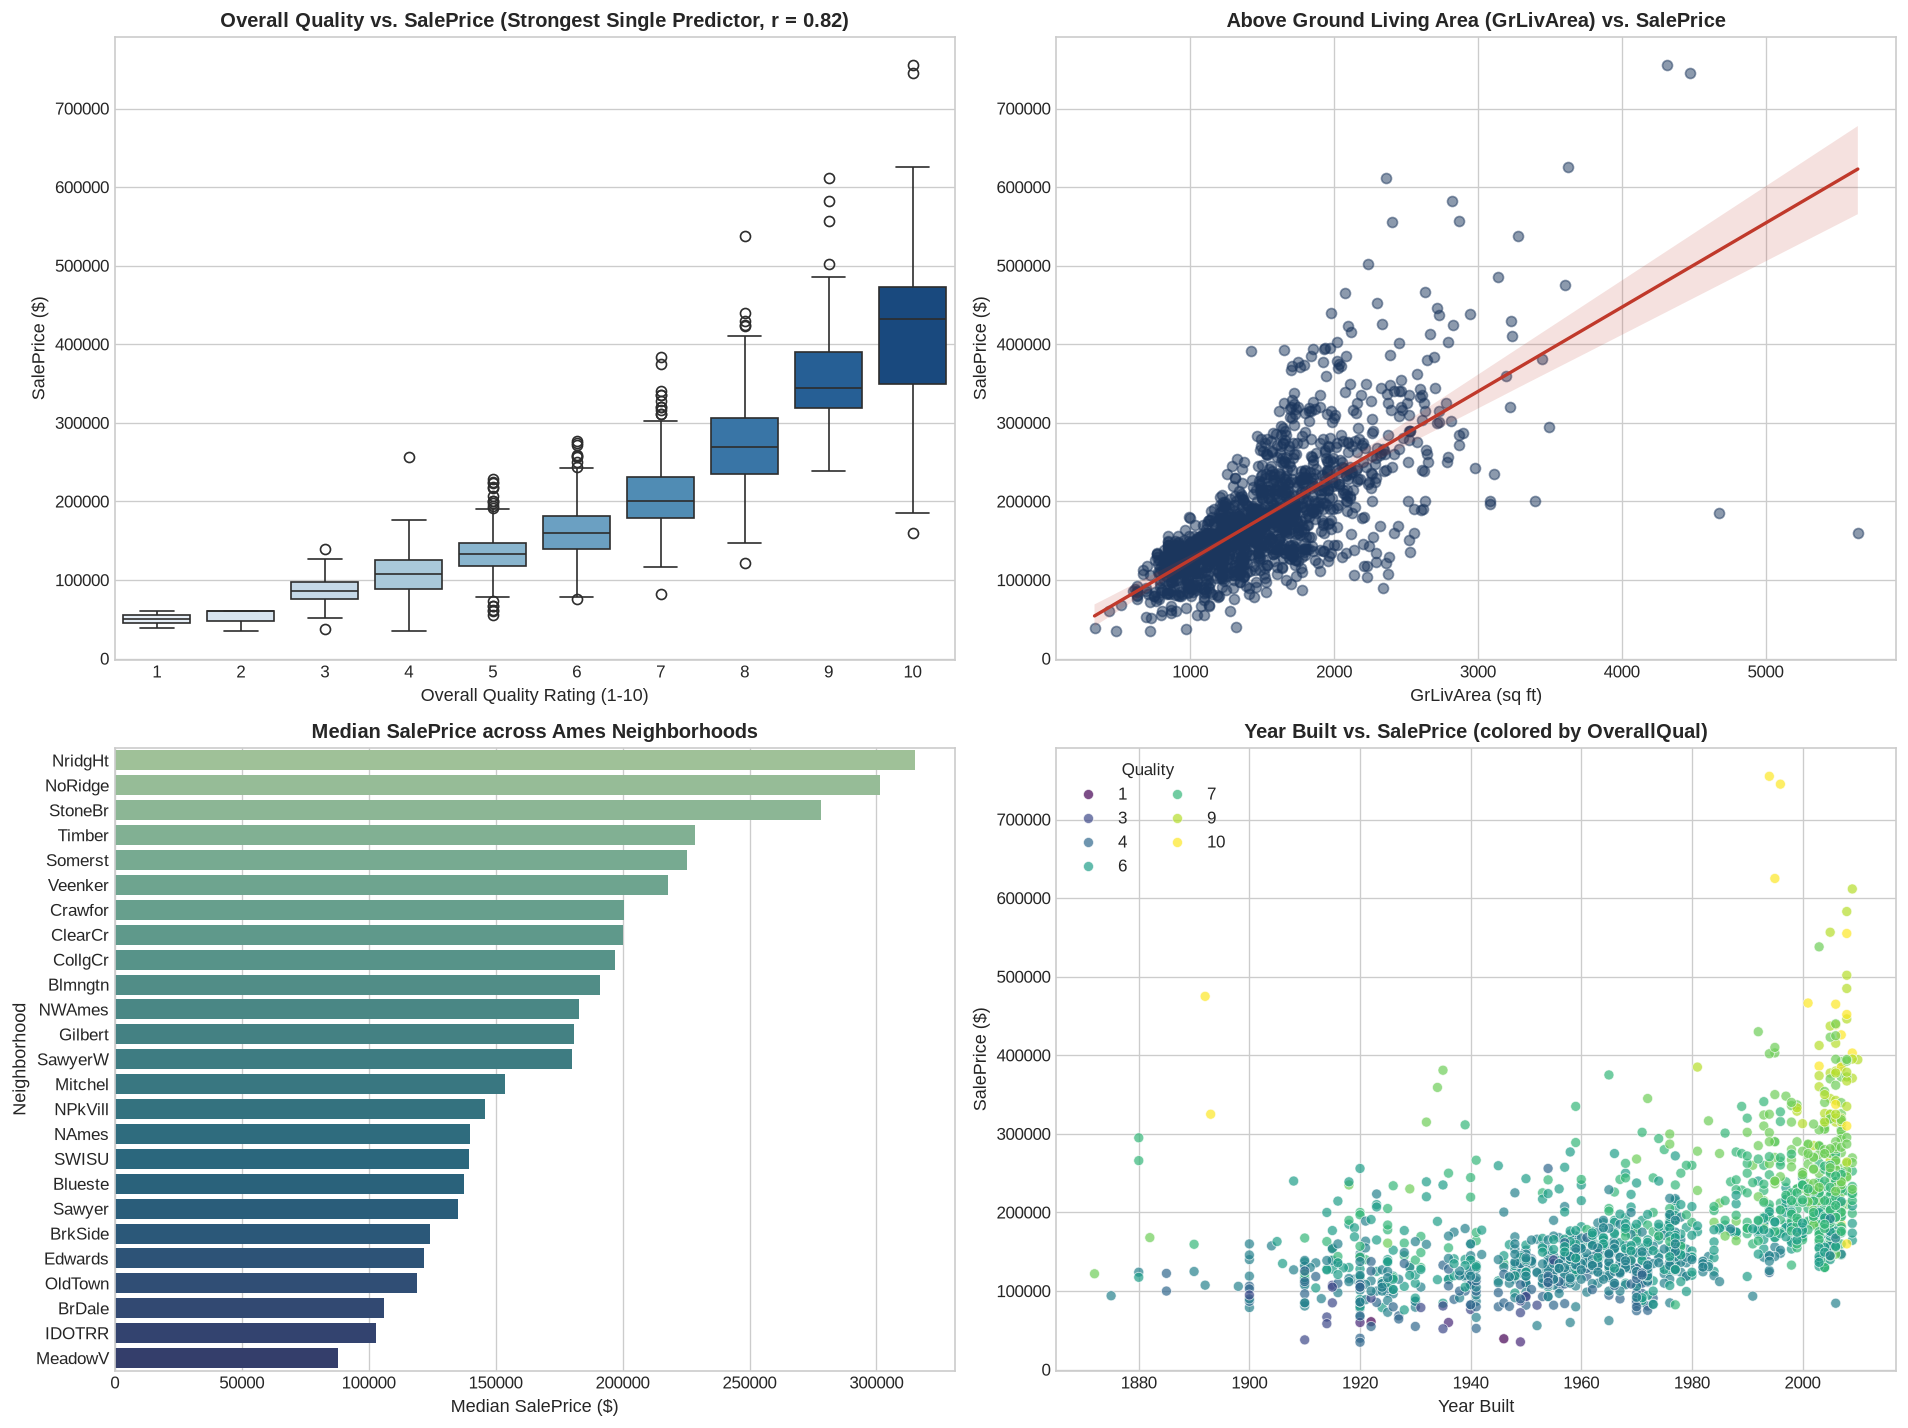

Saved figure: ../outputs/figures/04_key_feature_relationships.png


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. OverallQual vs SalePrice
sns.boxplot(x='OverallQual', y='SalePrice', data=train_df, ax=axes[0, 0], palette='Blues')
axes[0, 0].set_title('Overall Quality vs. SalePrice (Strongest Single Predictor, r = 0.82)', fontweight='bold')
axes[0, 0].set_ylabel('SalePrice ($)')
axes[0, 0].set_xlabel('Overall Quality Rating (1-10)')

# 2. GrLivArea vs SalePrice with Regression Trend
sns.regplot(x='GrLivArea', y='SalePrice', data=train_df, ax=axes[0, 1],
            scatter_kws={'alpha': 0.5, 'color': '#1B365D'}, line_kws={'color': '#C0392B', 'linewidth': 2})
axes[0, 1].set_title('Above Ground Living Area (GrLivArea) vs. SalePrice', fontweight='bold')
axes[0, 1].set_xlabel('GrLivArea (sq ft)')
axes[0, 1].set_ylabel('SalePrice ($)')

# 3. Neighborhood vs Median SalePrice
neighborhood_order = train_df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index
sns.barplot(x='SalePrice', y='Neighborhood', data=train_df, order=neighborhood_order,
            ax=axes[1, 0], estimator=np.median, errorbar=None, palette='crest')
axes[1, 0].set_title('Median SalePrice across Ames Neighborhoods', fontweight='bold')
axes[1, 0].set_xlabel('Median SalePrice ($)')

# 4. YearBuilt vs SalePrice
sns.scatterplot(x='YearBuilt', y='SalePrice', hue='OverallQual', data=train_df, 
                ax=axes[1, 1], palette='viridis', alpha=0.7)
axes[1, 1].set_title('Year Built vs. SalePrice (colored by OverallQual)', fontweight='bold')
axes[1, 1].set_xlabel('Year Built')
axes[1, 1].set_ylabel('SalePrice ($)')
axes[1, 1].legend(title='Quality', loc='upper left', ncol=2)

plt.tight_layout()
fig_path = os.path.join(FIG_DIR, '04_key_feature_relationships.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved figure: {fig_path}")


## 6. Outlier Detection & Anomaly Analysis
In the dataset documentation, dataset author **Dean De Cock** explicitly advises:
> *"There are 5 unusual sales in the data set that are easily spotted by plotting GrLivArea against SalePrice... I would recommend removing any houses with more than 4000 square feet from the data set (which eliminates these points) before attempting to model this data."*

Two of these sales reside in the training set (`Id` 524 and `Id` 1299). They represent enormous properties ($>4000$ sq ft) that were sold as partial/abnormal sales at unusually low prices.


In [26]:
extreme_size = train_df[train_df['GrLivArea'] > 4000]
print("Properties with GrLivArea > 4000 sq ft:")
display(extreme_size[['Id', 'GrLivArea', 'OverallQual', 'SaleCondition', 'SalePrice']])


Properties with GrLivArea > 4000 sq ft:


,Id,GrLivArea,OverallQual,SaleCondition,SalePrice
523,524,4676,10,Partial,184750
691,692,4316,10,Normal,755000
1182,1183,4476,10,Abnorml,745000
1298,1299,5642,10,Partial,160000


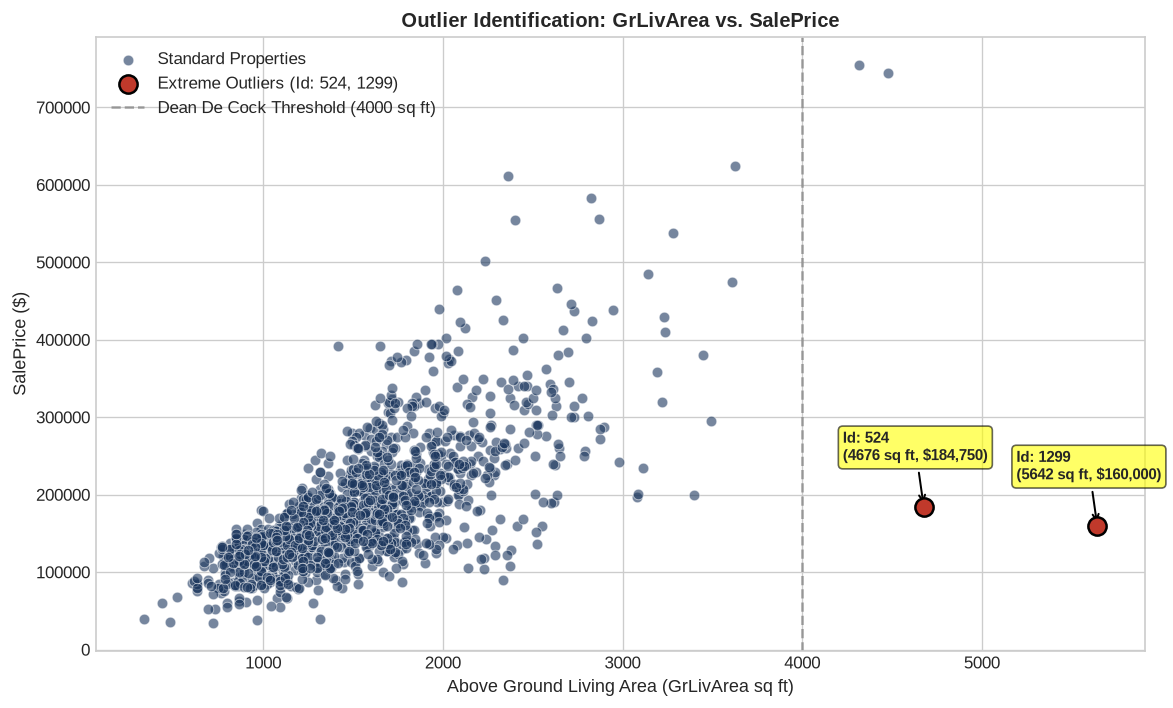

Saved figure: ../outputs/figures/05_outlier_analysis.png


In [27]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x='GrLivArea', y='SalePrice', data=train_df, color='#1B365D', alpha=0.6, s=40, label='Standard Properties')

outliers = train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)]
plt.scatter(outliers['GrLivArea'], outliers['SalePrice'], color='#C0392B', s=120, edgecolors='black', 
            linewidth=1.5, zorder=5, label='Extreme Outliers (Id: 524, 1299)')

for _, row in outliers.iterrows():
    label_txt = f"Id: {int(row['Id'])}\n({int(row['GrLivArea'])} sq ft, ${int(row['SalePrice']):,})"
    plt.annotate(label_txt,
                 xy=(row['GrLivArea'], row['SalePrice']),
                 xytext=(row['GrLivArea'] - 450, row['SalePrice'] + 60000),
                 arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.2),
                 fontsize=9, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.6))

plt.axvline(x=4000, color='gray', linestyle='--', alpha=0.7, label='Dean De Cock Threshold (4000 sq ft)')
plt.title('Outlier Identification: GrLivArea vs. SalePrice', fontweight='bold')
plt.xlabel('Above Ground Living Area (GrLivArea sq ft)')
plt.ylabel('SalePrice ($)')
plt.legend(loc='upper left')

plt.tight_layout()
fig_path = os.path.join(FIG_DIR, '05_outlier_analysis.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved figure: {fig_path}")


## 7. Key Findings & Preprocessing Roadmap

Based on this Exploratory Data Analysis, we formulate the following concrete decisions for **`02_preprocessing.ipynb`** and the machine learning pipeline:

| Component | Finding from EDA | Action in Preprocessing Pipeline |
| :--- | :--- | :--- |
| **Target Variable** | Right-skewed distribution (skew = 1.88, kurtosis = 6.54) | Apply `np.log1p()` during training; evaluate models using RMSE on log scale; apply `np.expm1()` on test predictions. |
| **Severe Outliers** | `Id 524` and `Id 1299` are massive houses ($>4000$ sq ft) sold abnormally below market price | Drop `Id 524` and `1299` from training set prior to training. |
| **Structural Missingness** | High missing percentage in `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`, `GarageType`, `BsmtQual` | Impute categorical NAs with `"None"` and numerical absence (e.g., `GarageArea = 0`) with `0`. |
| **Stochastic Missingness** | `LotFrontage` has 17.7% missing values correlated with neighborhood lot layout | Impute `LotFrontage` using the **median of the corresponding `Neighborhood`**. Impute `Electrical` with mode. |
| **Multicollinearity** | Redundancies in Garage (`Cars`/`Area`), Basement (`TotalBsmt`/`1stFlr`), Rooms | Keep all for tree ensembles; use $L_1$/$L_2$ regularization (Ridge, Lasso, ElasticNet) for linear models. |
| **Feature Engineering Opportunities** | High value in total house volume, composite bathrooms, and property age | 1. `TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF`<br>2. `TotalBath = FullBath + 0.5 * HalfBath + BsmtFullBath + 0.5 * BsmtHalfBath`<br>3. `HouseAge = YrSold - YearBuilt`<br>4. `RemodAge = YrSold - YearRemodAdd`<br>5. Binary indicators: `HasPool`, `Has2ndFloor`, `HasGarage`, `HasBasement`, `HasFireplace`. |
| **Validation Strategy** | Single train/test split has high variance due to small sample size ($N=1460$) | Implement **5-Fold Cross-Validation** with shuffle (`KFold(n_splits=5, shuffle=True, random_state=42)`). |
